# **SENSITIVITY ANALYSIS**

In [19]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('../data/Walmart.csv') #loading dataset
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.head() #dataset preview

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


As observed during EDA, store sizes range is too wide and running regressions on raw Weekly_Sales would skew our coefficients due to store sizes' dominance. Thus, converting raw Weekly_Sales to week-over-week percent change is necessary to put Weekly_Sales at scale.
A month variable will also be added to measure seasonality in addition to Holiday_Flag, as calendar months capture broader seasonal patterns than just the pure binary Holiday_Flag variable.

In [20]:
#converting to percent change to control for store size
df = df.sort_values(['Store', 'Date'])
df['Sales_Pct_Change'] = df.groupby('Store')['Weekly_Sales'].pct_change()

#defining month as seasonality in addition to Holiday_Flag binary variable
df['Month'] = df['Date'].dt.month

Let's fit our OLS regression: 
$$
\Delta Sales_{i,t} = \beta_0 + \beta_1 CPI_t + \beta_2 Unemployment_t + \beta_3 FuelPrice_t + \beta_4 Holiday_t + \sum_{m=2}^{12} \gamma_m \, Month_{m,t} + \varepsilon_{i,t}
$$ 

where:
- $\Delta Sales_{i,t}$ is the week-over-week percent change in sales for store $i$ in week $t$
- $CPI_t$, $Unemployment_t$, $FuelPrice_t$ are the macroeconomic variables of interest
- $Holiday_t$ is a binary indicator for holiday weeks
- $Month_{m,t}$ are calendar-month dummy variables (relative to January), controlling for seasonality
- $\varepsilon_{i,t}$ is the error term

$\beta_1$, $\beta_2$, and $\beta_3$ are the coefficients of interest: each store's sensitivity to CPI, unemployment, and fuel price respectively, estimated after controlling for holiday and monthly seasonal effects.
$\beta_4$ and $\gamma_m$ are control variables, not coefficients of interests.


In [21]:
#OLS regression
results = {} #storing each store's regression coefficient
pvalues = {} #stioring p-values to later check for statistical significance

for store_id in df['Store'].unique(): #looping through each unique store
    store_df = df[df['Store'] == store_id].dropna(subset=['Sales_Pct_Change']) #filtering for the store's rows and dropping first week due to lack of Sales_Pct_Change
    model = smf.ols( #fitting Ordinary Least Squares Regression for the store
        'Sales_Pct_Change ~ CPI + Unemployment + Fuel_Price + Holiday_Flag + C(Month)', #predict Sales_Pct_Change using CPI, unemployment, fuel_price and control for month and holidays
        data=store_df
    ).fit()
    results[store_id] = model.params #save the coefficients for the store 
    pvalues[store_id] = model.pvalues #save the p-values for the store

sensitivity_df = pd.DataFrame(results).T #convert results into a DF and transposing for rows
pvalues_df = pd.DataFrame(pvalues).T #convert p-values into a DF and transposing for rows
sensitivity_df.head()

,Intercept,C(Month)[T.2],C(Month)[T.3],C(Month)[T.4],C(Month)[T.5],C(Month)[T.6],C(Month)[T.7],C(Month)[T.8],C(Month)[T.9],C(Month)[T.10],C(Month)[T.11],C(Month)[T.12],CPI,Unemployment,Fuel_Price,Holiday_Flag
1,0.391483,0.042438,0.033052,0.009671,0.027087,0.018585,0.010288,0.040951,0.009055,0.030343,0.126891,-0.006322,-0.001423,-0.015693,0.004654,-0.015363
2,1.287557,0.041699,0.018517,0.020673,0.039582,0.022360,0.005644,0.037299,0.006496,0.031954,0.143078,0.006259,-0.005002,-0.033646,0.008106,-0.026785
3,-0.233364,0.041164,0.012312,0.027172,0.030142,0.033225,0.011163,0.040800,0.019007,0.033772,0.153719,-0.028400,0.000826,0.005206,-0.003264,0.007776
4,3.715588,0.054434,0.015993,0.022557,0.029014,0.015685,-0.001022,0.008898,0.013096,0.022014,0.117498,-0.009350,-0.027518,-0.035888,0.008144,-0.040313
5,-0.794654,0.011399,0.036552,0.045911,0.039856,0.025716,0.011572,0.055600,0.005818,0.028874,0.181911,-0.050770,0.003101,0.023484,-0.016419,0.058599


Preliminary observations for the first 5 stores:
- Unemployment coefficients are almost all negative except for stores 3 and 5: sales is lower when unemployment is higher.
- CPI coefficients are small: inconsistent and requires further review across all 45 stores
- Fuel_Price is consistently small and ranges across 0: requires further review across all 45 stores
- C(Month)[T.11]. is the largest positive coefficient in every row, confirming the Holiday effect (Thanksgiving)

In [22]:
#checking across 45 stores
sensitivity_df.describe()

,Intercept,C(Month)[T.2],C(Month)[T.3],C(Month)[T.4],C(Month)[T.5],C(Month)[T.6],C(Month)[T.7],C(Month)[T.8],C(Month)[T.9],C(Month)[T.10],C(Month)[T.11],C(Month)[T.12],CPI,Unemployment,Fuel_Price,Holiday_Flag
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,1.017753,0.033823,0.022227,0.020973,0.040755,0.019264,0.008342,0.033285,0.001321,0.029915,0.129314,-0.017601,-0.005520,-0.031723,-0.004083,0.003253
std,1.799785,0.038563,0.035793,0.032022,0.047014,0.042268,0.036614,0.042405,0.028037,0.040556,0.082534,0.041858,0.011998,0.046262,0.022276,0.049975
min,-2.252494,-0.089927,-0.061636,-0.053185,-0.055457,-0.070575,-0.087208,-0.080594,-0.063882,-0.068475,-0.036364,-0.143536,-0.032995,-0.222428,-0.070882,-0.085813
25%,-0.022182,0.016743,-0.002022,0.009671,0.022196,0.004660,-0.007388,0.008898,-0.014077,0.018650,0.119058,-0.035391,-0.008001,-0.051031,-0.013939,-0.026785
50%,0.391483,0.041164,0.024921,0.027172,0.039856,0.019662,0.011572,0.042486,0.004842,0.036945,0.143078,-0.015196,-0.001225,-0.022302,-0.001899,-0.008863
75%,1.952430,0.057133,0.044183,0.038182,0.063651,0.037233,0.025454,0.056558,0.013096,0.055891,0.178593,-0.002272,0.000826,0.000262,0.007570,0.026111
max,5.359146,0.098973,0.095183,0.098721,0.148169,0.159134,0.099263,0.104228,0.075517,0.095279,0.289240,0.113288,0.018205,0.023484,0.036569,0.146543


Observations for our 3 coefficients of interest:
- CPI with mean of -0.0055, ranging from -0.033 to 0.018: low negative effect overall and range across 0 means the effect is weak and inconsistent. 75th percentile is mostly negative but small effect size.
- Unemployment with mean of -0.0317, ranging from -0.222 to 0.023: median and 75th percentile shows most stores have a negative coefficient, consistent finding that shows rising unemployment is correlated with negative sales growth. Standard deviation of 0.0463 is large relative to mean, which shows stores vary significantly in how unemployment-sensitive they are. However, the range across 0 also shows that the effect is weak.
- Fuel_Price with mean of -0.0041, ranging -0.071 to 0.037: weak effect overall as range across 0. 75th percentile suggests a mixed pattern.

To verify whether the findings are significant, check the p-values.

In [23]:
pvalues_df[['CPI', 'Unemployment', 'Fuel_Price']].head()

,CPI,Unemployment,Fuel_Price
1,0.806820,0.747007,0.908862
2,0.702545,0.664859,0.862481
3,0.925510,0.930187,0.954847
4,0.325851,0.296063,0.868071
5,0.798802,0.817506,0.792323


In [24]:
significance_threshold = 0.05

print("Stores with statistically significant CPI effect:",
      (pvalues_df['CPI'] < significance_threshold).sum(), "/ 45")

print("Stores with statistically significant Unemployment effect:",
      (pvalues_df['Unemployment'] < significance_threshold).sum(), "/ 45")

print("Stores with statistically significant Fuel_Price effect:",
      (pvalues_df['Fuel_Price'] < significance_threshold).sum(), "/ 45")

Stores with statistically significant CPI effect: 0 / 45
Stores with statistically significant Unemployment effect: 0 / 45
Stores with statistically significant Fuel_Price effect: 0 / 45


After checking the p-values, we see that the results are not statistically significant. This may be a sample size problem, as each store only has weekly observations (about 143). 
To further investigate, we will be running a pooled regression across all stores at once with store fixed effects. 

$$
\Delta Sales_{i,t} = \beta_0 + \beta_1 \Delta CPI_{i,t} + \beta_2 \Delta Unemployment_{i,t} + \beta_3 \Delta FuelPrice_{i,t} + \beta_4 Holiday_t + \sum_{m=2}^{12} \gamma_m \, Month_{m,t} + \sum_{s=2}^{45} \delta_s \, Store_{s} + \varepsilon_{i,t}
$$

where:
- $\Delta Sales_{i,t}$ is the week-over-week percent change in sales for store $i$ in week $t$
- $\Delta CPI_{i,t}$, $\Delta Unemployment_{i,t}$, $\Delta FuelPrice_{i,t}$ are the week-over-week **changes** in the macroeconomic variables (matching the transformation applied to sales, rather than using raw levels)
- $Holiday_t$ is a binary indicator for holiday weeks
- $Month_{m,t}$ are calendar-month dummy variables, controlling for seasonality
- $Store_s$ are store fixed effects, absorbing each store's own baseline level and idiosyncrasies
- $\varepsilon_{i,t}$ is the error term, with standard errors **clustered by store** to correct for non-independent errors within each store's time series

$\beta_1$, $\beta_2$, and $\beta_3$ are the coefficients of interest. $\beta_4$, $\gamma_m$, and $\delta_s$ are control variables, not coefficients of interest.

In [25]:
# Convert macro variables to week-over-week change
df = df.sort_values(['Store', 'Date'])
df['CPI_Change'] = df.groupby('Store')['CPI'].diff()
df['Unemployment_Change'] = df.groupby('Store')['Unemployment'].diff()
df['Fuel_Price_Change'] = df.groupby('Store')['Fuel_Price'].diff()

#fit OLS regression across all stores
pooled_model = smf.ols(
    'Sales_Pct_Change ~ CPI_Change + Unemployment_Change + Fuel_Price_Change + Holiday_Flag + C(Month) + C(Store)',
    data=df.dropna(subset=['Sales_Pct_Change', 'CPI_Change', 'Unemployment_Change', 'Fuel_Price_Change'])
).fit()

print(pooled_model.params[['CPI_Change', 'Unemployment_Change', 'Fuel_Price_Change']])
print(pooled_model.pvalues[['CPI_Change', 'Unemployment_Change', 'Fuel_Price_Change']])
print(f"R-squared: {pooled_model.rsquared:.4f}")

CPI_Change            -0.010211
Unemployment_Change   -0.231718
Fuel_Price_Change     -0.018219
dtype: float64
CPI_Change             5.221748e-01
Unemployment_Change    4.878674e-27
Fuel_Price_Change      4.783963e-01
dtype: float64
R-squared: 0.0820


Under the threshold of p < 0.05, only Unemployment_Change is statistically significant, while the p-values for CPI_Change (0.52) and Fuel_Price_Change (0.48) show that they are not. However, the p-value for Unemployment_Change is extremely low, pretty much outruling all possibilities for noises and random errors. This suggests that there may be issues with our initial assumptions and mathematical setup.
Let's check further by clustering the standard errors by store.

In [26]:
pooled_model_clustered = smf.ols(
    'Sales_Pct_Change ~ CPI_Change + Unemployment_Change + Fuel_Price_Change + Holiday_Flag + C(Month) + C(Store)',
    data=df.dropna(subset=['Sales_Pct_Change', 'CPI_Change', 'Unemployment_Change', 'Fuel_Price_Change'])
).fit(cov_type='cluster', cov_kwds={'groups': df.dropna(subset=['Sales_Pct_Change', 'CPI_Change', 'Unemployment_Change', 'Fuel_Price_Change'])['Store']})

print(pooled_model_clustered.pvalues[['CPI_Change', 'Unemployment_Change', 'Fuel_Price_Change']])

CPI_Change             3.404824e-02
Unemployment_Change    7.943070e-13
Fuel_Price_Change      5.065992e-01
dtype: float64


Clustering significantly increased the magnitude of the p-value for Unemployment_Change while remaining still statistically significant. Fuel_Price_Change pretty much stays the same, but CPI_Change is now statistically significant after clustering.

Based on our findings, we confirmed that: on average, across all stores, unemployment changes have a causal relationship with sales growth. As unemployment increases, sales decreases.
The original, basic OLS regression by store failed to show statistical significant. However, for the sake of exploratory findings, we will assume that the results of this regression holds true and proceed with k-means clustering to explore potentials of risk-tiers.

In [27]:
cluster_features = sensitivity_df[['CPI', 'Unemployment', 'Fuel_Price']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features) #standardize to avoid dominance due to scale

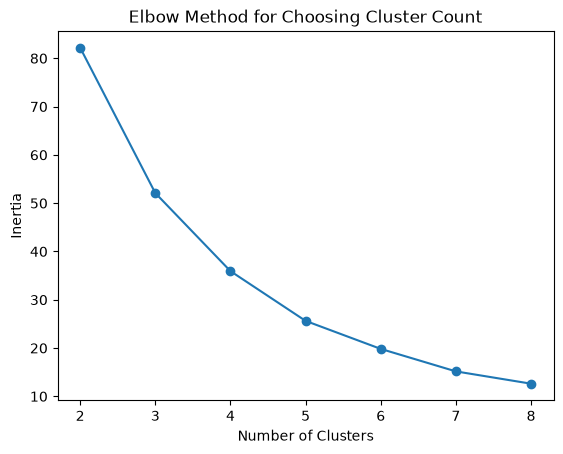

In [28]:
#Clustering counts 2-8 and tracking fit
inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

plt.plot(range(2, 9), inertias, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Choosing Cluster Count')
plt.show()

Observing the chart above, we see that the visible "bend" sits at around k = 4 or k = 5. Any k below 4 is leaving out information, while k above 5 is adding too much noise for very little fit. We will be going with k = 4 for the sake of business interpretability.

In [29]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10) #fitting final k-means model with k = 4
sensitivity_df['Cluster'] = kmeans_final.fit_predict(scaled_features) #assign each store to a cluster
cluster_profile = sensitivity_df.groupby('Cluster')[['CPI', 'Unemployment', 'Fuel_Price']].mean() #average CPI/unemployment/Fuel_Price sensitivity per cluster
cluster_profile

,CPI,Unemployment,Fuel_Price
Cluster,,,
0,-0.001427,-0.009460,0.000243
1,-0.029239,-0.193784,-0.046656
2,0.004581,-0.033713,-0.030160
3,-0.021721,-0.055560,0.019441


In [30]:
print(sensitivity_df['Cluster'].value_counts()) #counting number of stores in each cluster
tier_names = { #naming each cluster by risk coefficient
    0: 'Stable',
    1: 'High-Risk',
    2: 'Resilient',
    3: 'Moderately Exposed'
}
sensitivity_df['Risk_Tier'] = sensitivity_df['Cluster'].map(tier_names) #mapping tier names to numeric cluster
sensitivity_df[['Cluster', 'Risk_Tier']].head(10)

Cluster
0    25
3     9
2     9
1     2
Name: count, dtype: int64


,Cluster,Risk_Tier
1,0,Stable
2,0,Stable
3,0,Stable
4,3,Moderately Exposed
5,0,Stable
6,0,Stable
7,0,Stable
8,0,Stable
9,0,Stable
10,3,Moderately Exposed


In [31]:
sensitivity_df[sensitivity_df['Risk_Tier'] == 'High-Risk']

,Intercept,C(Month)[T.2],C(Month)[T.3],C(Month)[T.4],C(Month)[T.5],C(Month)[T.6],C(Month)[T.7],C(Month)[T.8],C(Month)[T.9],C(Month)[T.10],C(Month)[T.11],C(Month)[T.12],CPI,Unemployment,Fuel_Price,Holiday_Flag,Cluster,Risk_Tier
26,5.359146,0.054338,0.079920,0.098721,0.148169,0.091345,0.092411,0.100941,0.075517,0.056340,0.148634,0.022241,-0.025483,-0.222428,-0.070882,0.024612,1,High-Risk
40,5.279340,0.080119,0.064812,0.039961,0.091728,0.045170,0.042067,0.056558,0.049959,0.057977,0.131968,0.025139,-0.032995,-0.165141,-0.022430,-0.026241,1,High-Risk


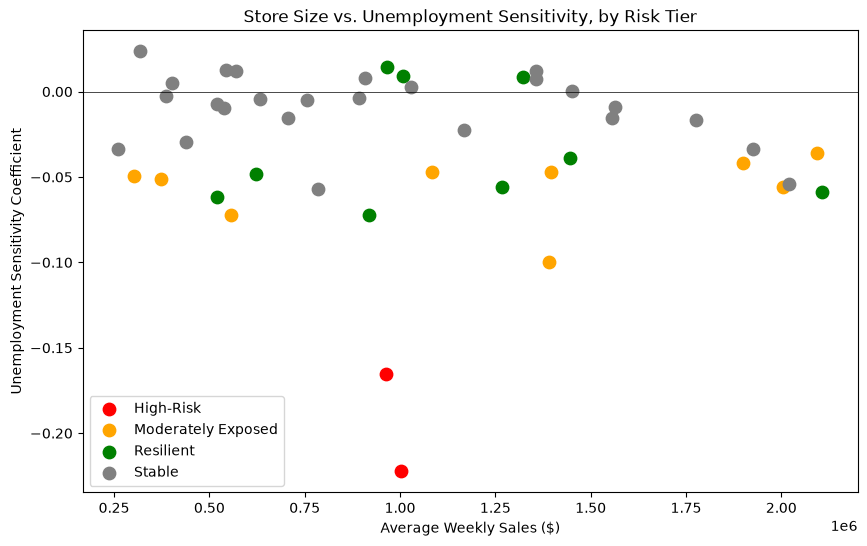

In [32]:
# Merge store size into the sensitivity table for plotting
sensitivity_df['Avg_Weekly_Sales'] = store_average

# Assign a color per risk tier for the scatter plot
colors = {'Stable': 'gray', 'Resilient': 'green', 'Moderately Exposed': 'orange', 'High-Risk': 'red'}

plt.figure(figsize=(10,6))
for tier, group in sensitivity_df.groupby('Risk_Tier'):
    plt.scatter(group['Avg_Weekly_Sales'], group['Unemployment'],
                label=tier, color=colors[tier], s=80)

plt.xlabel('Average Weekly Sales ($)')
plt.ylabel('Unemployment Sensitivity Coefficient')
plt.title('Store Size vs. Unemployment Sensitivity, by Risk Tier')
plt.axhline(0, color='black', linewidth=0.5)
plt.legend()
plt.show()

We now have our descriptive risk tier classifications. However, these results are purely descriptive and do not have statistical significance.

In [33]:
sensitivity_df.to_csv('../data/sensitivity_results.csv')
# Save the validated pooled coefficients for Phase 3's scenario modeling
pooled_results = pd.DataFrame({
    'coefficient': pooled_model_clustered.params[['CPI_Change', 'Unemployment_Change', 'Fuel_Price_Change']],
    'p_value': pooled_model_clustered.pvalues[['CPI_Change', 'Unemployment_Change', 'Fuel_Price_Change']]
})
pooled_results.to_csv('../data/pooled_model_results.csv')